In [5]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Hyperparameters
INPUT_DIM = 2
COUPLING_DIM = 256
COUPLING_LAYERS = 4
BATCH_SIZE = 256
LR = 1e-4
EPOCHS = 50
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset
class MoonsDataset(Dataset):
    def __init__(self, n_samples=30000, noise=0.05):
        data, _ = make_moons(n_samples=n_samples, noise=noise)
        self.data = ((data - data.mean(0)) / data.std(0)).astype(np.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [6]:
class CouplingLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.scale_net = nn.Sequential(
            nn.Linear(input_dim // 2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim // 2), nn.Tanh())

        self.translate_net = nn.Sequential(
            nn.Linear(input_dim // 2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim // 2))

    def forward(self, x, mask, reverse=False):
        x_a = x * mask
        x_b = x * (1 - mask)

        # Pass only x_a's non-zero dimensions to the networks
        x_a_cond = x_a[:, mask.bool()]

        s = self.scale_net(x_a_cond)
        t = self.translate_net(x_a_cond)

        if not reverse:
            y_b = (x_b[:, (1 - mask).bool()] * torch.exp(s)) + t
            log_det_jac = s.sum(dim=1)
        else:
            y_b = (x_b[:, (1 - mask).bool()] - t) * torch.exp(-s)
            log_det_jac = -s.sum(dim=1)

        # Reconstruct the output
        y = torch.zeros_like(x)
        y[:, mask.bool()] = x_a_cond
        y[:, (1 - mask).bool()] = y_b

        return y, log_det_jac


# RealNVP Model
class RealNVP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_flows):
        super().__init__()
        self.prior = torch.distributions.MultivariateNormal(torch.zeros(input_dim).to(DEVICE), torch.eye(input_dim).to(DEVICE))
        self.layers = nn.ModuleList([CouplingLayer(input_dim, hidden_dim) for _ in range(num_flows)])
        self.masks = [torch.tensor([i % 2, (i+1) % 2]).float().to(DEVICE) for i in range(num_flows)]

    def forward(self, x):
        log_det_J = 0
        for layer, mask in zip(self.layers, self.masks):
            x, log_det = layer(x, mask)
            log_det_J += log_det
        return x, log_det_J

    def loss(self, x):
        z, log_det_J = self(x)
        log_prob = self.prior.log_prob(z)
        return -(log_det_J + log_prob).mean()

    def sample(self, num_samples):
        z = self.prior.sample((num_samples,))
        for layer, mask in reversed(list(zip(self.layers, self.masks))):
            z, _ = layer(z, mask, reverse=True)
        return z

In [7]:
def train(model, loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        tqdm_loader = tqdm(loader, desc=f"Training RealNVP - Epoch {epoch+1}/{epochs}")

        for batch in tqdm_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            loss = model.loss(batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            tqdm_loader.set_postfix(loss=loss.item())

        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {total_loss:.6f} ")


Training RealNVP - Epoch 1/50:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [1/50], Train Loss: 284.788055 


Training RealNVP - Epoch 2/50:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [2/50], Train Loss: 235.476307 


Training RealNVP - Epoch 3/50:   0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch [48/50], Train Loss: 147.587019 


Training RealNVP - Epoch 49/50:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [49/50], Train Loss: 146.754880 


Training RealNVP - Epoch 50/50:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [50/50], Train Loss: 148.022133 


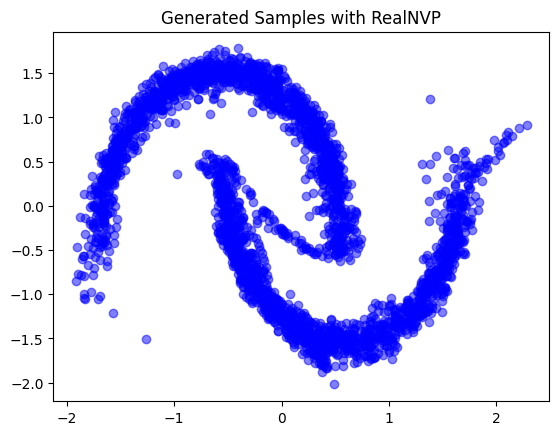

In [8]:
dataset = MoonsDataset()
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = RealNVP(INPUT_DIM, COUPLING_DIM, COUPLING_LAYERS).to(DEVICE)

train(model, loader, EPOCHS, LR)

# Sampling
samples = model.sample(3000).cpu().detach().numpy()

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, color='blue')
plt.title('Generated Samples with RealNVP')
plt.show()
